# MH-MCMC on the Planck CMB power spectrum
## Estimating $H_0$, $\Omega_b h^2$, $\Omega_c h^2$, $A_s$, $n_s$

Same method as the Pantheon notebooks: a short standard MH run to get the covariance matrix,
then a preconditioned run using that covariance.

Only the model changes -- instead of the distance modulus from `integrate.quad`, the theory
curve is $D_\ell^{TT}$ from CAMB, compared against the spectrum measured in `CMB_Planck.ipynb`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import healpy as hp
import camb
import corner

ModuleNotFoundError: No module named 'healpy'

---
Same two helpers as before.

In [ ]:
#Defining Chi squared function

def chi_sq(obs, theo, err):
    obs= np.array(obs)
    theo=np.array(theo)
    err=np.array(err)
    chi_squared=np.sum(((obs-theo)/err)**2)
    return chi_squared

In [ ]:
def plot_hist_with_gaussian(data, param_name, bins=50, color='#7F77DD'):
    """Histogram of MCMC samples with a fitted Gaussian overlay."""
    data = np.asarray(data)

    # Fit a Gaussian: returns (mean, std) that best match the sample distribution
    mu, sigma = stats.norm.fit(data)

    fig, ax = plt.subplots(figsize=(6, 4))

    counts, bin_edges, _ = ax.hist(data, bins=bins, density=True,
                                    color=color, alpha=0.6,
                                    edgecolor='white', linewidth=0.3,
                                    label='MCMC samples')

    x = np.linspace(data.min(), data.max(), 300)
    pdf = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, color='black', lw=2,
            label=f'Gaussian fit\n$\\mu$={mu:.7f}, $\\sigma$={sigma:.7f}')

    ax.axvline(mu, color='red', linestyle='--', lw=0.8)

    ax.set_xlabel(param_name)
    ax.set_ylabel('Probability density')
    ax.set_title(f'Posterior distribution: {param_name}')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return mu, sigma

---
## The data

`APS_anafast.txt` has one $D_\ell$ per multipole, which is far too noisy to fit point by point.
So we average them into bands of 30 multipoles each ("bandpowers"), and fit those instead.

We also cut $\ell < 30$ (too few modes for a Gaussian $\chi^2$) and $\ell > 1500$
(the $1/b_\ell^2 p_\ell^2$ correction blows the noise up past there).

In [ ]:
ell, cl_obs, dl_obs = np.loadtxt("Saved Data/APS_anafast.txt", skiprows=1, unpack=True)
ell = ell.astype(int)

LMIN, LMAX, DL_BIN = 30, 1000, 10                
F_SKY = 0.7780                                   # from np.mean(mask**2) in CMB_Planck.ipynb 

bl = hp.gauss_beam(np.radians(5/60), lmax=LMAX)  # same 5' beam and pixel window
pl = hp.pixwin(2048)[:LMAX + 1]                  # as were divided out in CMB_Planck.ipynb

# group the multipoles into bands of width DL_BIN
edges   = np.arange(LMIN, LMAX + 1, DL_BIN)
bin_idx = [np.where((ell >= edges[b]) & (ell < edges[b+1]))[0] for b in range(len(edges) - 1)]

def bin_it(y):
    return np.array([y[i].mean() for i in bin_idx])

l_eff  = bin_it(ell.astype(float))
D_data = bin_it(dl_obs)

print(f"{len(l_eff)} bandpowers, from l = {l_eff[0]:.0f} to {l_eff[-1]:.0f}")

97 bandpowers, from l = 34 to 994


---
## The model

CAMB gives the theory $D_\ell$ for a set of cosmological parameters -- exactly like the
`plot_camb_spectrum_variation` function in `CMB_camb.ipynb`, just wrapped so the MCMC can call it.

One extra parameter beyond the cosmology: `A_N`, the instrument noise level. The map has noise in it,
and dividing by $b_\ell^2 p_\ell^2$ blew that noise up at high $\ell$, so it has to go in the model
too or the fit gets dragged around. It's a nuisance parameter -- we fit it and then ignore it.

$\tau$ is held fixed at 0.054, because TT data alone can't separate it from $A_s$.

In [ ]:
# noise shape: white noise pushed through the same beam/pixel correction as the data
l_arr = np.arange(LMAX + 1)
prefac = np.zeros(LMAX + 1)
prefac[2:] = l_arr[2:] * (l_arr[2:] + 1) / (2 * np.pi)
D_noise_shape = prefac / (bl * pl)**2

def CAMB_DL(H0, ombh2, omch2, logA, ns):
    """Theory D_l^TT from CAMB, in uK^2 (same convention as CMB_camb.ipynb)."""
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=0.06, omk=0, tau=0.054)
    pars.InitPower.set_params(As=1e-10 * np.exp(logA), ns=ns)
    pars.set_for_lmax(LMAX + 250, lens_potential_accuracy=0)
    results = camb.get_results(pars)
    return results.get_cmb_power_spectra(pars, CMB_unit="muK")["total"][:LMAX+1, 0]

def MODEL(theta):
    """Binned theory bandpowers for theta = [H0, ombh2, omch2, logA, ns, A_N]."""
    H0, ombh2, omch2, logA, ns, A_N = theta
    return bin_it(CAMB_DL(H0, ombh2, omch2, logA, ns) + A_N * D_noise_shape)


---
## Error bars

The Pantheon data came with its own `dmb` column. Here there's no error column, so we have to work
out the uncertainty ourselves.

For a power spectrum it's mostly **cosmic variance**: there are only $2\ell+1$ independent
$a_{\ell m}$ at each $\ell$, so even a perfect experiment has a scatter of
$\sigma(C_\ell)/C_\ell=\sqrt{2/(2\ell+1)}$. Masking most of the sky leaves fewer modes still, hence
the $f_{\rm sky}$. Averaging $n$ multipoles into a band shrinks it by a further $\sqrt{n}$:

$$\sigma^2(D_b)=\frac{1}{n_b^2}\sum_{\ell\,\in\,b}\frac{2}{(2\ell+1)f_{\rm sky}}\left(D_\ell\right)^2$$

evaluated at a fiducial (Planck 2018) model plus noise.

In [ ]:
dl_fid = CAMB_DL(67.4, 0.02237, 0.1200, 3.044, 0.9649)
N_b, F_b = bin_it(D_noise_shape), bin_it(dl_fid)

# fit the noise level A_N to the data (the model is linear in A_N, so this is just least squares)
A_N_fid = 1e-4
for _ in range(5):
    D_tot = dl_fid + A_N_fid * D_noise_shape
    var_b = np.array([np.sum(2.0 / ((2*ell[i] + 1) * F_SKY) * D_tot[i]**2) / len(i)**2
                      for i in bin_idx])
    A_N_fid = np.sum((D_data - F_b) * N_b / var_b) / np.sum(N_b**2 / var_b)

sig_b = np.sqrt(var_b)
print(f"noise level A_N = {A_N_fid:.3e}  ->  {np.degrees(np.sqrt(A_N_fid))*60:.1f} uK-arcmin")
print(f"chi_sq of the fiducial model = {chi_sq(D_data, F_b + A_N_fid*N_b, sig_b):.1f}"
      f"  for {len(l_eff)} bandpowers")

noise level A_N = 6.508e-04  ->  87.7 uK-arcmin
chi_sq of the fiducial model = 106.6  for 97 bandpowers


---
# Standard and Adaptive MH MCMC

#### First, the standard method to get the covariance matrix

Small number of iterations, to avoid time consuming computation.

In [ ]:
bounds = np.array([
    [50.0,   90.0  ],    # H0
    [0.015,  0.030 ],    # Omega_b h^2
    [0.08,   0.18  ],    # Omega_c h^2
    [2.6,    3.5   ],    # ln(10^10 As)
    [0.85,   1.05  ],    # n_s
    [0.0,    5e-3  ]])   # A_N  (noise nuisance)

labels = ['$H_0$', '$\\Omega_b h^2$', '$\\Omega_c h^2$',
          '$\\ln(10^{10}A_s)$', '$n_s$', '$A_N$']
names  = ['H0', 'ombh2', 'omch2', 'logA', 'ns', 'A_N']

def in_bounds(theta):
    return np.all((bounds[:, 0] <= theta) & (theta <= bounds[:, 1]))

def chi2_at(theta):
    try:
        return chi_sq(D_data, MODEL(theta), sig_b)
    except Exception:
        return np.inf          # CAMB occasionally fails in odd corners of the parameter space

In [ ]:
# step sizes for the standard run
deltas = np.aray([0.15, 4e-5, 3e-4, 1.5e-3, 1.2e-3, 8e-7])
N_iterations = 5000

for nm, b, d in zip(names, bounds, deltas):
    print(f'{nm:>6} range: [{b[0]}, {b[1]}],  delta: {d}')
print(f'\nN_iterations = {N_iterations}')

    H0 range: [50.0, 90.0],  delta: 0.15
 ombh2 range: [0.015, 0.03],  delta: 4e-05
 omch2 range: [0.08, 0.18],  delta: 0.0003
  logA range: [2.6, 3.5],  delta: 0.0015
    ns range: [0.85, 1.05],  delta: 0.0012
   A_N range: [0.0, 0.005],  delta: 8e-07

N_iterations = 5000


In [ ]:
mcmc_df = pd.DataFrame(columns=names + ['Chi_sq', 'Type'])

theta_prev = np.array([67.4, 0.02237, 0.1200, 3.044, 0.9649, A_N_fid])   # start at Planck values, to minimize the burn-in steps
chi_sq1 = chi2_at(theta_prev)
print("Initial values:", np.round(theta_prev, 5))
print("Chi_squared initial:", chi_sq1, '\n')

print("Begin MH-MCMC\n")
for nstep in range(N_iterations):
    theta_new = theta_prev + deltas * np.random.normal(0, 1, len(deltas))

    type_val = 3
    if in_bounds(theta_new):
        chi_sq2 = chi2_at(theta_new)
        if chi_sq2 <= chi_sq1:
            theta_prev, chi_sq1 = theta_new, chi_sq2
            type_val = 1
        elif np.exp(-(chi_sq2 - chi_sq1) / 2) > np.random.uniform(0, 1):
            theta_prev, chi_sq1 = theta_new, chi_sq2
            type_val = 2

    # every step goes in the chain, accepted or not
    mcmc_df.loc[len(mcmc_df)] = list(theta_prev) + [chi_sq1, type_val]

    if type_val < 3:
        print(f'{nstep}) -- type {type_val}, H0 = {theta_prev[0]:.3f}, '
              f'ombh2 = {theta_prev[1]:.5f}, omch2 = {theta_prev[2]:.4f}, chi_sq: {chi_sq1:.2f}')

print("\nFinal values:", np.round(theta_prev, 5))
print("Final Chi_sq value:", chi_sq1)
print(f"Acceptance rate: {(mcmc_df['Type'] < 3).mean():.1%}")

Initial values: [6.740e+01 2.237e-02 1.200e-01 3.044e+00 9.649e-01 6.500e-04]
Chi_squared initial: 106.6309417631007 

Begin MH-MCMC

0) -- type 1, H0 = 67.360, ombh2 = 0.02230, omch2 = 0.1198, chi_sq: 102.91
2) -- type 1, H0 = 67.285, ombh2 = 0.02225, omch2 = 0.1197, chi_sq: 97.85
4) -- type 1, H0 = 67.240, ombh2 = 0.02222, omch2 = 0.1194, chi_sq: 94.90
5) -- type 2, H0 = 67.174, ombh2 = 0.02222, omch2 = 0.1200, chi_sq: 103.97
6) -- type 1, H0 = 67.143, ombh2 = 0.02223, omch2 = 0.1198, chi_sq: 99.19
7) -- type 2, H0 = 67.079, ombh2 = 0.02226, omch2 = 0.1200, chi_sq: 100.86
8) -- type 1, H0 = 67.116, ombh2 = 0.02224, omch2 = 0.1201, chi_sq: 97.62
9) -- type 2, H0 = 67.298, ombh2 = 0.02228, omch2 = 0.1200, chi_sq: 97.65
10) -- type 2, H0 = 67.144, ombh2 = 0.02227, omch2 = 0.1197, chi_sq: 101.46
13) -- type 1, H0 = 67.257, ombh2 = 0.02226, omch2 = 0.1199, chi_sq: 96.43
16) -- type 1, H0 = 67.219, ombh2 = 0.02222, omch2 = 0.1199, chi_sq: 94.24
17) -- type 1, H0 = 67.173, ombh2 = 0.02219, 

Discarded 25 burn-in rows, 4975 remain


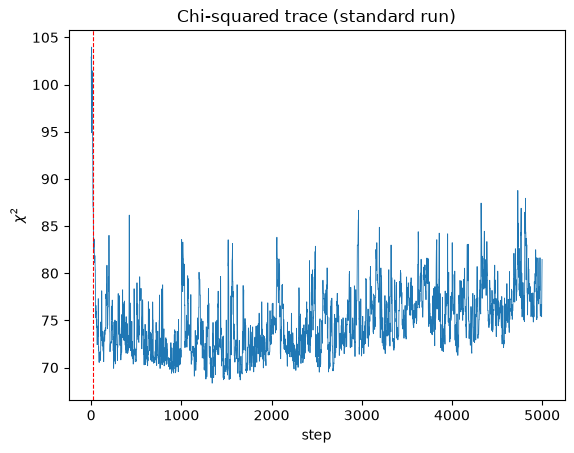

In [ ]:
#Removing the Burnt-in Values
final_chi_sq = mcmc_df['Chi_sq'].iloc[-1]
first_valid_index = mcmc_df[mcmc_df['Chi_sq'] < 1.05*final_chi_sq].index[0]
trimmed_df = mcmc_df.loc[first_valid_index:]
print(f"Discarded {first_valid_index} burn-in rows, {len(trimmed_df)} remain")

plt.plot(mcmc_df['Chi_sq'].values, lw=0.6)
plt.axvline(first_valid_index, color='red', ls='--', lw=0.8)
plt.xlabel('step'); plt.ylabel(r'$\chi^2$')
plt.title('Chi-squared trace (standard run)')
plt.show()

#### Now the preconditioned run

The covariance from the short chain becomes the proposal distribution, scaled by $2.38^2/d$.

This matters much more here than it did for Pantheon: $H_0$ and $\Omega_c h^2$ are correlated at
about $-0.97$ in this fit, so a proposal that steps each parameter independently almost never lands
anywhere the data likes.

In [ ]:
n_iter = 50000
d = len(bounds)

prev = trimmed_df[names].to_numpy().astype(float)
cov = (2.38**2 / d) * np.cov(prev.T)     # Roberts & Rosenthal optimal scaling
print("Proposal covariance from previous chain:\n", cov)

# correlation matrix, easier to read than the covariance
sd = np.sqrt(np.diag(cov))
print("\nCorrelations:\n", pd.DataFrame(np.round(cov / np.outer(sd, sd), 2),
                                        index=names, columns=names))

Proposal covariance from previous chain:
 [[ 1.24010260e+00  2.57672541e-04 -2.39324545e-03 -4.39647189e-03
   8.53457362e-03 -8.87571746e-06]
 [ 2.57672541e-04  8.15771614e-08 -4.18110465e-07 -6.16779872e-07
   1.84892522e-06 -1.78121779e-09]
 [-2.39324545e-03 -4.18110465e-07  5.17936648e-06  1.05721362e-05
  -1.62361275e-05  1.88680236e-08]
 [-4.39647189e-03 -6.16779872e-07  1.05721362e-05  2.61686656e-05
  -2.98617674e-05  3.50366319e-08]
 [ 8.53457362e-03  1.84892522e-06 -1.62361275e-05 -2.98617674e-05
   7.20497180e-05 -6.78975408e-08]
 [-8.87571746e-06 -1.78121779e-09  1.88680236e-08  3.50366319e-08
  -6.78975408e-08  1.66596051e-10]]

Correlations:
          H0  ombh2  omch2  logA    ns   A_N
H0     1.00   0.81  -0.94 -0.77  0.90 -0.62
ombh2  0.81   1.00  -0.64 -0.42  0.76 -0.48
omch2 -0.94  -0.64   1.00  0.91 -0.84  0.64
logA  -0.77  -0.42   0.91  1.00 -0.69  0.53
ns     0.90   0.76  -0.84 -0.69  1.00 -0.62
A_N   -0.62  -0.48   0.64  0.53 -0.62  1.00


In [ ]:
# --- plain Metropolis with that FIXED covariance ---
theta = prev[-1].copy()                  # start where the standard run finished
chi2_curr = chi2_at(theta)

chain = np.empty((n_iter, d))
chi2_chain = np.empty(n_iter)
n_accepted = 0

for n in range(n_iter):
    theta_new = np.random.multivariate_normal(theta, cov)   # cov never changes
    if in_bounds(theta_new):
        chi2_new = chi2_at(theta_new)
        if chi2_new <= chi2_curr or np.exp(-(chi2_new - chi2_curr)/2) > np.random.uniform():
            theta, chi2_curr = theta_new, chi2_new
            n_accepted += 1
    chain[n] = theta
    chi2_chain[n] = chi2_curr

    if (n + 1) % 250 == 0:
        print(f"{n+1}/{n_iter}  acc={n_accepted/(n+1):.1%}  chi2={chi2_curr:.1f}  "
              , flush=True)

print(f"\nAcceptance rate: {n_accepted/n_iter:.1%}")   # ~23% is optimal (Roberts et al. 1997)
mcmc_df_adap = pd.DataFrame(chain, columns=names)
mcmc_df_adap['Chi_sq'] = chi2_chain
mcmc_df_adap.to_csv("Saved Data/mcmc_cmb_chain.csv", index=False)

250/50000  acc=32.0%  chi2=71.7  
500/50000  acc=35.2%  chi2=69.5  
750/50000  acc=34.3%  chi2=70.4  
1000/50000  acc=34.0%  chi2=73.7  
1250/50000  acc=34.4%  chi2=71.6  
1500/50000  acc=34.9%  chi2=70.7  
1750/50000  acc=34.6%  chi2=74.4  
2000/50000  acc=35.6%  chi2=68.5  
2250/50000  acc=35.2%  chi2=70.6  
2500/50000  acc=35.4%  chi2=74.9  
2750/50000  acc=34.4%  chi2=66.7  
3000/50000  acc=34.4%  chi2=73.3  
3250/50000  acc=34.2%  chi2=78.7  
3500/50000  acc=34.2%  chi2=66.3  
3750/50000  acc=34.2%  chi2=69.9  
4000/50000  acc=34.3%  chi2=72.6  
4250/50000  acc=34.0%  chi2=70.2  
4500/50000  acc=33.8%  chi2=73.6  
4750/50000  acc=33.7%  chi2=68.4  
5000/50000  acc=33.8%  chi2=76.6  
5250/50000  acc=33.7%  chi2=73.7  
5500/50000  acc=33.7%  chi2=71.6  
5750/50000  acc=33.8%  chi2=67.2  
6000/50000  acc=33.8%  chi2=74.5  
6250/50000  acc=33.7%  chi2=72.0  
6500/50000  acc=33.7%  chi2=70.1  
6750/50000  acc=33.6%  chi2=68.6  
7000/50000  acc=33.5%  chi2=73.3  
7250/50000  acc=33.4%  

---
## Results

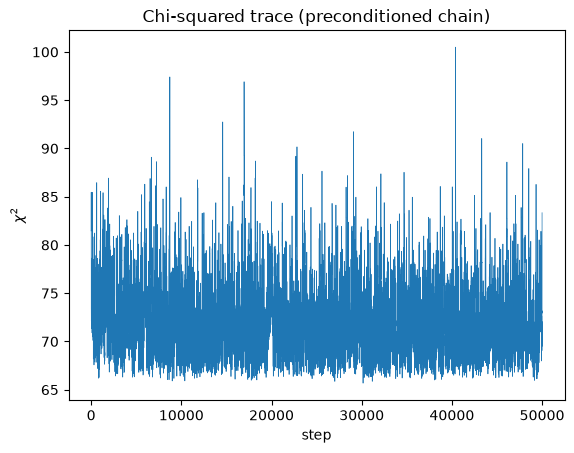

Discarded 500 burn-in rows, 49500 remain


In [ ]:
# --- diagnostic trace + burn-in cut ---
df = pd.read_csv("Saved Data/mcmc_cmb_chain.csv")

plt.plot(df['Chi_sq'].values, lw=0.5)
plt.xlabel('step'); plt.ylabel(r'$\chi^2$')
plt.title('Chi-squared trace (preconditioned chain)')
plt.show()

BURN = 500
trimmed_df = df.loc[BURN:]
print(f"Discarded {BURN} burn-in rows, {len(trimmed_df)} remain")

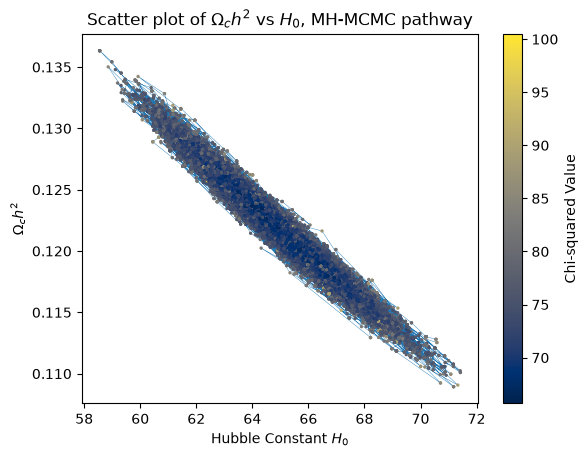

In [3]:
# Scatter plot of Omega_c h^2 vs H_0 MH-MCMC pathway
plt.plot(trimmed_df['H0'], trimmed_df['omch2'], linewidth=0.3, zorder=1)
plt.scatter(trimmed_df['H0'], trimmed_df['omch2'], c=trimmed_df['Chi_sq'],
            cmap='cividis', s=2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_c h^2$')
plt.title('Scatter plot of $\u03A9_c h^2$ vs $H_0$, MH-MCMC pathway')
plt.show()

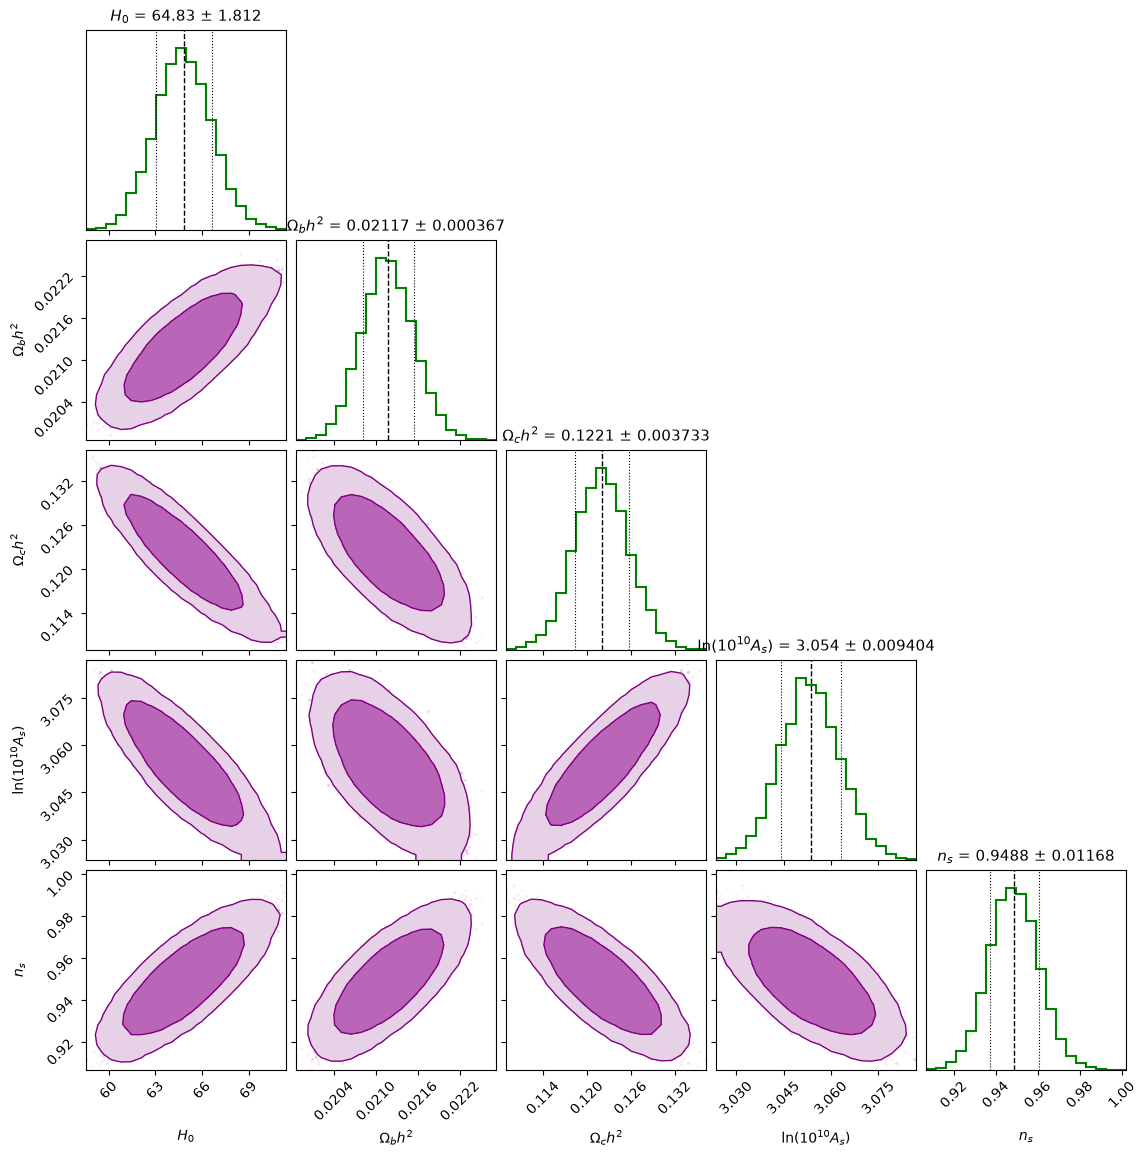

In [6]:
plot_names  = names[:-1]          # or names[:5]
plot_labels = labels[:-1]

samples = trimmed_df[plot_names].to_numpy()

# 2σ and 3σ in 2D
sigmas = np.array([2., 3.])
levels = 1.0 - np.exp(-0.5 * sigmas**2)   # -> [0.8647, 0.9889]

figure = corner.corner(samples, color='purple',
    levels=levels,
    labels=plot_labels,
    fill_contours=True,
    plot_datapoints=True,    # kill the scatter
    plot_density=False,       # kill the underlying 2D histogram shading
    no_fill_contours=False,
    smooth=1.0,               # smooths the 2D contours
    smooth1d=None,
    show_titles=False,
    hist_kwargs={"color": "green", "lw": 1.5},
    contour_kwargs={"linewidths": 1},
    contourf_kwargs={"colors": ['white', '#d8b3d8', '#8B008B'], "alpha": 0.6})

ndim = samples.shape[1]
axes = np.array(figure.axes).reshape((ndim, ndim))
mu = samples.mean(axis=0)
sd = samples.std(axis=0, ddof=1)

for i in range(ndim):
    ax = axes[i, i]
    ax.set_title(rf"{labels[i]} = {mu[i]:.4g} $\pm$ {sd[i]:.4g}", fontsize=11)
    ax.axvline(mu[i], color='k', ls='--', lw=1)
    ax.axvline(mu[i] - sd[i], color='k', ls=':', lw=0.8)
    ax.axvline(mu[i] + sd[i], color='k', ls=':', lw=0.8)

figure.savefig("Saved Data/mcmc_cmb_corner.png", dpi=200, bbox_inches="tight")

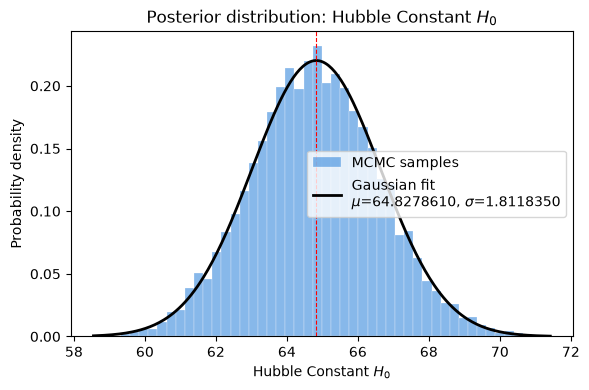

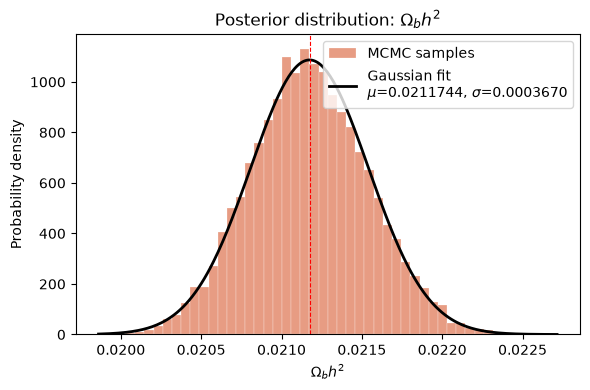

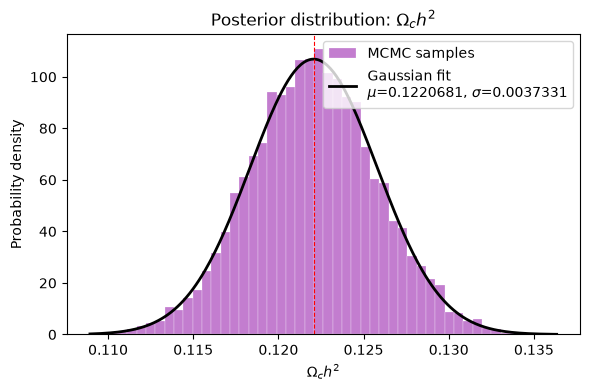

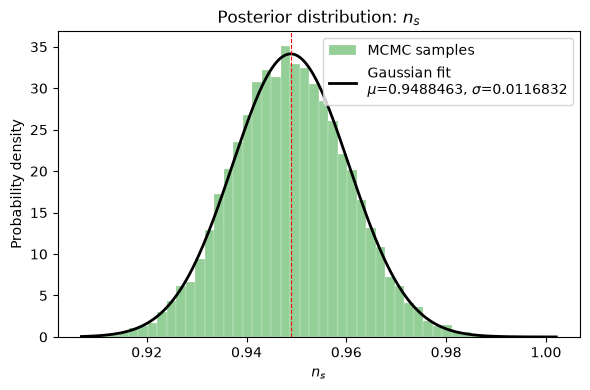

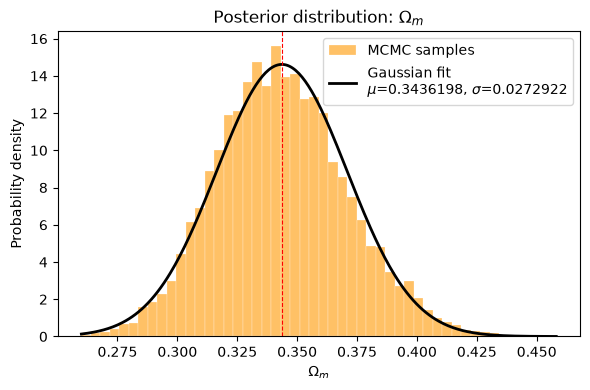

H0          = 64.83 +/- 1.81 km/s/Mpc
Omega_b h^2 = 0.02117 +/- 0.00037
Omega_c h^2 = 0.1221 +/- 0.0037
n_s         = 0.9488 +/- 0.0117
Omega_m     = 0.3436 +/- 0.0273   (derived)


In [ ]:
H0_mean,   H0_std   = plot_hist_with_gaussian(trimmed_df['H0'], 'Hubble Constant $H_0$',
                                                color='#378ADD')
obh2_mean, obh2_std = plot_hist_with_gaussian(trimmed_df['ombh2'], '$\\Omega_b h^2$',
                                                color='#D85A30')
och2_mean, och2_std = plot_hist_with_gaussian(trimmed_df['omch2'], '$\\Omega_c h^2$',
                                                color='#9C27B0')
ns_mean,   ns_std   = plot_hist_with_gaussian(trimmed_df['ns'], '$n_s$',
                                                color='#4CAF50')

# derived: total matter density
Om = (trimmed_df['ombh2'] + trimmed_df['omch2'] + 0.06/93.14) / (trimmed_df['H0']/100)**2
Om_mean, Om_std = plot_hist_with_gaussian(Om, '$\\Omega_m$', color='#FF9800')

print(f"H0          = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_b h^2 = {obh2_mean:.5f} +/- {obh2_std:.5f}")
print(f"Omega_c h^2 = {och2_mean:.4f} +/- {och2_std:.4f}")
print(f"n_s         = {ns_mean:.4f} +/- {ns_std:.4f}")
print(f"Omega_m     = {Om_mean:.4f} +/- {Om_std:.4f}   (derived)")

Best fit: {'H0': np.float64(64.69919), 'ombh2': np.float64(0.02115), 'omch2': np.float64(0.12227), 'logA': np.float64(3.05382), 'ns': np.float64(0.94804), 'A_N': np.float64(0.00054)}
chi_sq = 65.7 for 97 bandpowers, 91 dof


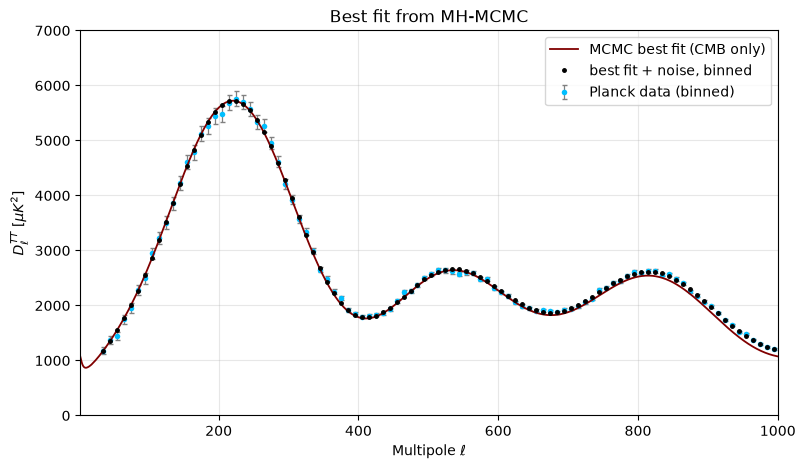

In [ ]:
# best fit vs data
best = trimmed_df.loc[trimmed_df['Chi_sq'].idxmin(), plot_names].to_numpy().astype(float)
print("Best fit:", dict(zip(plot_names, np.round(best, 5))))
print(f"chi_sq = {chi2_at(best):.1f} for {len(l_eff)} bandpowers, {len(l_eff)-d} dof")

plt.figure(figsize=(9, 5))
plt.errorbar(l_eff, D_data, yerr=sig_b, fmt='o', mfc='deepskyblue', mec='none', ms=4,
             ecolor='gray', capsize=1.8, elinewidth=0.9, label='Planck data (binned)', zorder=1)
plt.plot(l_arr[2:], CAMB_DL(*best[:5])[2:], color='maroon', lw=1.3,
         label='MCMC best fit (CMB only)', zorder=2)
plt.plot(l_eff, MODEL(best), 'k.', ms=5, label='best fit + noise, binned', zorder=3)

plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell^{TT}\ [\mu K^2]$')
plt.title('Best fit from MH-MCMC')
plt.xlim(2, LMAX); plt.ylim(0, 7000)
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig("Saved Data/mcmc_cmb_bestfit.png", dpi=300, bbox_inches="tight")
plt.show()

---
## A note on the numbers

Expect these to sit a few $\sigma$ away from the published Planck values. That's the spectrum
estimation, not the fitting:

* the mask correlates neighbouring multipoles, and dividing by $f_{\rm sky}$ only corrects this
  approximately (the full correction is the MASTER coupling matrix);
* COMMANDER leaves some foreground residuals at high $\ell$, which get absorbed into $A_N$;
* the real noise isn't white or uniform across the sky.

Quickest check: rerun with `LMAX = 1000` and see whether the parameters shift. If they do,
high-$\ell$ systematics are driving the fit.